In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pickle
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [2]:
df = pd.read_csv("stds_performance.csv")
df.describe() 


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [3]:
print("----------------------- Checking null values -----------------------")
print (df.isna()) #Checking for null values

print ("----------------------- Counting missing values per column -----------------------")
print(df.isna().sum()) # checking null values in each column

print ("----------------------- Dropping rows with NaN values -----------------------")
new_df = df.dropna() #dropping rows with null values

print("----------------------- verifying whether null values is removed or not -----------------------")
new_df.isna().sum()# checking for null values after removing them

----------------------- Checking null values -----------------------
      StudentID    Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0         False  False   False      False              False            False   
1         False  False   False      False              False            False   
2         False  False   False      False              False            False   
3         False  False   False      False              False            False   
4         False  False   False      False              False            False   
...         ...    ...     ...        ...                ...              ...   
2387      False  False   False      False              False            False   
2388      False  False   False      False              False            False   
2389      False  False   False      False              False            False   
2390      False  False   False      False              False            False   
2391      False  False   False      Fals

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [4]:
# Checking for duplicate rows in the DataFrame 'new_df'
duplicates = new_df.duplicated()  

# Counting the total number of duplicate rows by adding the True values
total_duplicates = duplicates.sum()  

# Displaying the total number of duplicates found
total_duplicates
# Remove duplicates (if any)
new_df = new_df.drop_duplicates()
new_df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [6]:
# Counting total number of columns in the dataframe
total_columns = len(new_df.columns)

# Print total columns
print("Total number of columns:", total_columns)


print("------------------Column Names-----------------")

# Loop through each column name in the dataframe
for column in new_df.columns:
    print(column)  #  this prints column name one by one

Total number of columns: 15
------------------Column Names-----------------
StudentID
Age
Gender
Ethnicity
ParentalEducation
StudyTimeWeekly
Absences
Tutoring
ParentalSupport
Extracurricular
Sports
Music
Volunteering
GPA
GradeClass


In [7]:
# Check current data types
print(new_df.dtypes)

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


In [8]:
# Convert columns to integer type
int_cols = [
    'StudentID', 'Age', 'Gender', 'Ethnicity',
    'ParentalEducation', 'Absences', 'Tutoring',
    'ParentalSupport', 'Extracurricular',
    'Sports', 'Music', 'Volunteering', 'GradeClass'
]

for col in int_cols:
    new_df[col] = new_df[col].astype(int)

# Convert columns to float type
new_df['StudyTimeWeekly'] = new_df['StudyTimeWeekly'].astype(float)
new_df['GPA'] = new_df['GPA'].astype(float)

# Verify updated data types
print(new_df.dtypes)

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass             int64
dtype: object


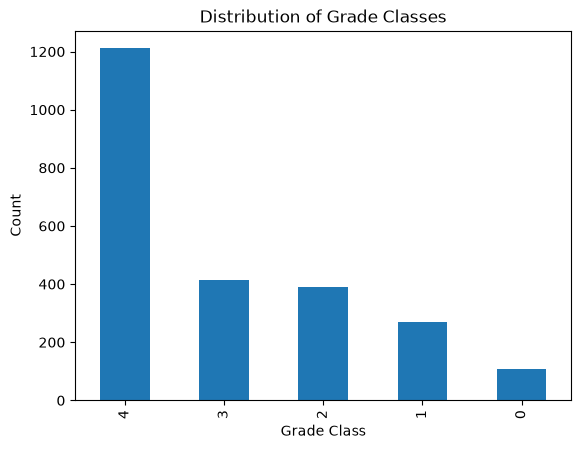

In [13]:
#check distribution of grade class
new_df['GradeClass'].value_counts().plot(kind='bar')
plt.title('Distribution of Grade Classes')
plt.xlabel('Grade Class')
plt.ylabel('Count')
plt.show()

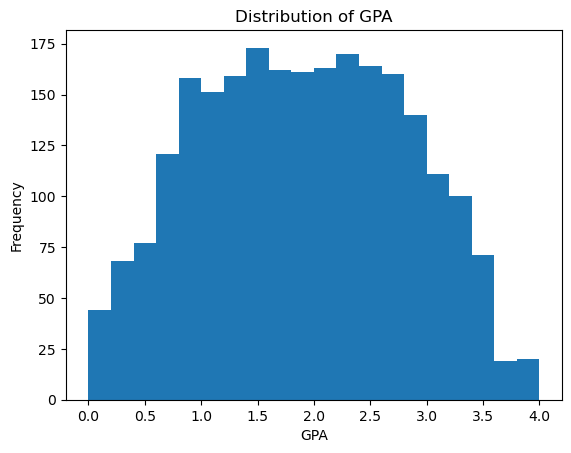

In [12]:
# GPA distribution
plt.hist(new_df['GPA'], bins=20)
plt.title('Distribution of GPA')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.show()

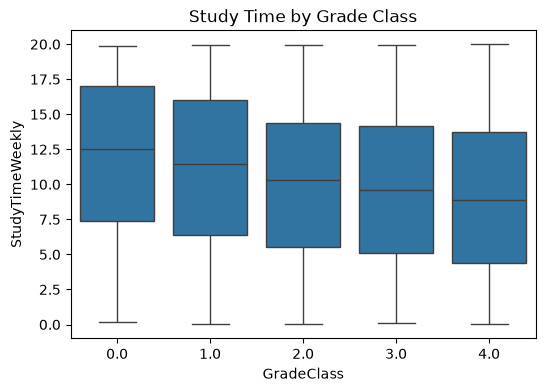

In [9]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="GradeClass",
    y="StudyTimeWeekly",
    data=df
)

plt.title("Study Time by Grade Class")

plt.show()

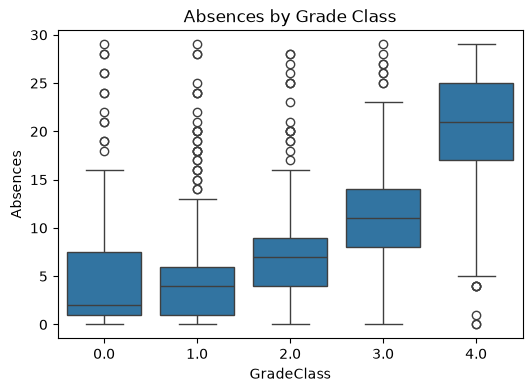

In [10]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="GradeClass",
    y="Absences",
    data=df
)

plt.title("Absences by Grade Class")

plt.show()

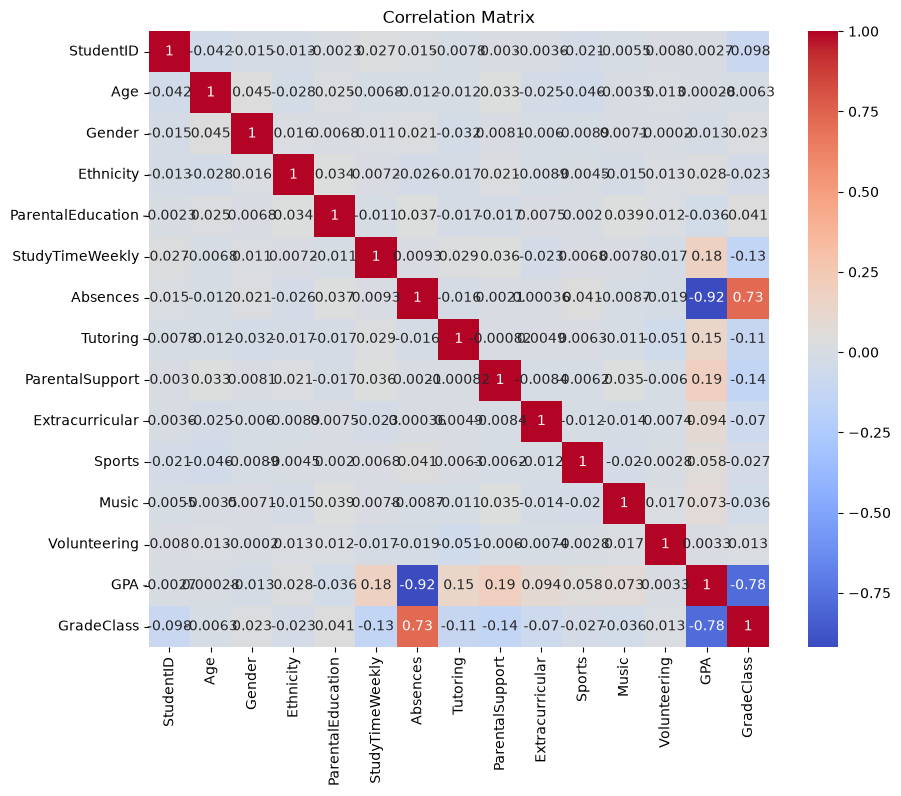

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

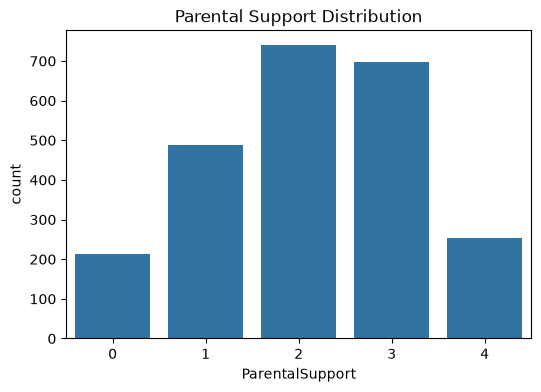

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="ParentalSupport",
    data=df
)

plt.title("Parental Support Distribution")

plt.show()

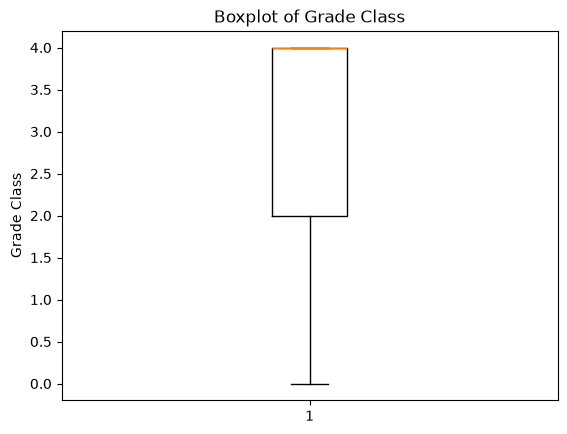

In [15]:
# Outlier Detection
plt.boxplot(new_df['GradeClass'])
plt.title('Boxplot of Grade Class')
plt.ylabel('Grade Class')
plt.show()

# For GradeClass Prediction

# Feature Selection

In [5]:
X = new_df.drop(
    ["StudentID", "GPA", "GradeClass"],
    axis=1
)

y = new_df["GradeClass"]

# Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model Training


In [7]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

# Prediction and Accuracy

In [9]:
y_pred = rf.predict(X_test)

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.6951983298538622


In [15]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

         0.0       0.67      0.09      0.16        22
         1.0       0.48      0.51      0.50        49
         2.0       0.48      0.51      0.49        85
         3.0       0.53      0.45      0.49        86
         4.0       0.86      0.95      0.90       237

    accuracy                           0.70       479
   macro avg       0.60      0.50      0.51       479
weighted avg       0.68      0.70      0.68       479



# Confusion Matrix

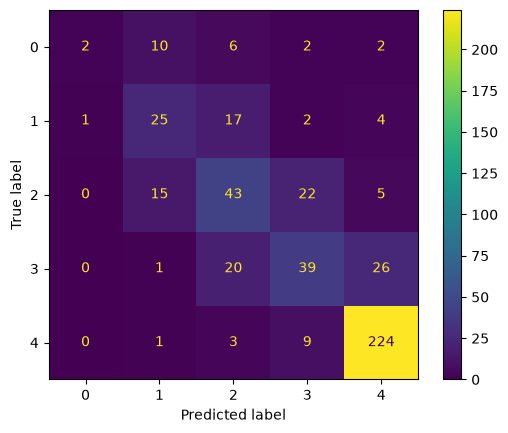

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# Feature Importance

In [9]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
5            Absences    0.447875
4     StudyTimeWeekly    0.168869
7     ParentalSupport    0.064642
3   ParentalEducation    0.059954
0                 Age    0.057499
2           Ethnicity    0.052440
1              Gender    0.030541
9              Sports    0.027537
8     Extracurricular    0.026547
6            Tutoring    0.022908
10              Music    0.022491
11       Volunteering    0.018696


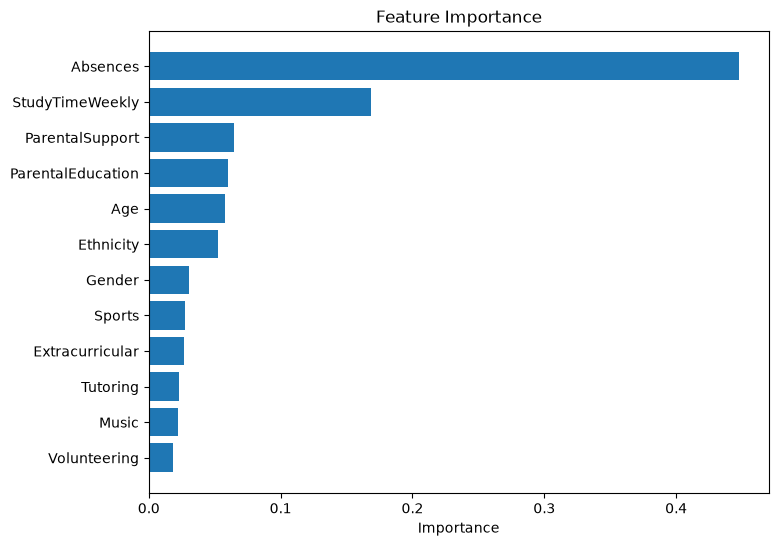

In [10]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

# Cross Validation

In [ ]:


scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("Average Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.74321503 0.73277662 0.71757322 0.73640167 0.58158996]
Average Accuracy:
0.7023113005651593
